### Environment
Use the Jupyter kernel "Python (simtilt_env)". Package install cell has been removed since dependencies are managed by the virtual environment.

In [1]:
# Config and imports
import os
import math
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
from shapely.geometry import LineString, Point
import shapely
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from tqdm import tqdm

ox.settings.log_console=False
ox.settings.use_cache=True

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Study area and parameters
PLACE = "Lausanne, Switzerland"  # change as needed
GRAPH_NETWORK_TYPE = "drive"
N_PAIRS = 50  # number of random origin-destination pairs
LATERAL_A_MAX = 0.1 * 9.81  # 0.1 g in m/s^2
STOP_PENALTY_S = 8.0  # seconds lost per stop (traffic light, roundabout entry)
MIN_EDGE_LENGTH_FOR_CURVATURE_M = 5.0  # filter too-short edges for curvature estimation

# Plot settings
sns.set_context("talk")
sns.set_style("whitegrid")


In [2]:
# Load and prepare OSM graph (robust)
print(f"Downloading graph for {PLACE} ...")
try:
    G = ox.graph_from_place(PLACE, network_type=GRAPH_NETWORK_TYPE, simplify=True)
except Exception as e:
    print(f"graph_from_place failed: {e}\nFalling back to geocode -> geometry")
    pgdf = ox.geocode_to_gdf(PLACE)
    # make geometries valid
    pgdf["geometry"] = pgdf["geometry"].apply(lambda g: shapely.make_valid(g) if g is not None else g)
    geoms = [g for g in pgdf.geometry.tolist() if g is not None and not g.is_empty]
    poly = None
    try:
        if len(geoms) == 1:
            poly = geoms[0]
        elif len(geoms) > 1:
            poly = shapely.union_all(geoms)
    except Exception as e2:
        print(f"union_all failed: {e2}")
    if poly is not None:
        G = ox.graph_from_polygon(poly, network_type=GRAPH_NETWORK_TYPE, simplify=True)
    else:
        minx, miny, maxx, maxy = pgdf.total_bounds
        # note: bbox args are north, south, east, west
        G = ox.graph_from_bbox(maxy, miny, maxx, minx, network_type=GRAPH_NETWORK_TYPE, simplify=True)
print("Done!")
G = ox.project_graph(G)

# Add speed/travel time attributes
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# Basic stats
stats = ox.basic_stats(G)
print({k: stats[k] for k in ["edge_length_total", "street_length_total", "intersection_count"]})

# Build GeoDataFrames for edges and nodes
edges_gdf = ox.utils_graph.graph_to_gdfs(G, nodes=False, fill_edge_geometry=True)
nodes_gdf = ox.utils_graph.graph_to_gdfs(G, edges=False)
print(f"Edges: {len(edges_gdf)}, Nodes: {len(nodes_gdf)}")


Done!
{'edge_length_total': 398430.109, 'street_length_total': 231915.622, 'intersection_count': np.int64(1173)}
Edges: 3022, Nodes: 1343


C:\Users\arche\AppData\Local\Temp\ipykernel_47876\651093456.py:37: FutureWarning: The `graph_to_gdfs` function has moved to the `convert` module. Calling `utils_graph.graph_to_gdfs` is deprecated and will be removed in the v2.0.0 release. Call it via `convert.graph_to_gdfs` instead. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  edges_gdf = ox.utils_graph.graph_to_gdfs(G, nodes=False, fill_edge_geometry=True)
C:\Users\arche\AppData\Local\Temp\ipykernel_47876\651093456.py:38: FutureWarning: The `graph_to_gdfs` function has moved to the `convert` module. Calling `utils_graph.graph_to_gdfs` is deprecated and will be removed in the v2.0.0 release. Call it via `convert.graph_to_gdfs` instead. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  nodes_gdf = ox.utils_graph.graph_to_gdfs(G, edges=False)


In [3]:
# Sample random node pairs within bounding polygon
# Filter to largest connected component for routing robustness
Gc = ox.utils_graph.get_largest_component(G, strongly=False)
Gc = nx.freeze(Gc)
print(f"Graph nodes: {len(G.nodes)}, edges: {len(G.edges)}")
print(f"Largest component nodes: {len(Gc.nodes)}, edges: {len(Gc.edges)}")
node_ids = list(Gc.nodes)

test_orig, test_dest = node_ids[0], node_ids[1]
try:
    test_route = ox.shortest_path(Gc, test_orig, test_dest, weight="length")
    print("Test route found:", test_route)
except Exception as e:
    print("Test route failed:", e)

pairs: List[Tuple[int, int]] = []
while len(pairs) < N_PAIRS:
    a, b = np.random.choice(node_ids, size=2, replace=False)
    if a == b:
        continue
    pairs.append((int(a), int(b)))

len(pairs), pairs[:3]


Graph nodes: 1343, edges: 3022
Largest component nodes: 1343, edges: 3022
Test route found: [280571, 581059576]


C:\Users\arche\AppData\Local\Temp\ipykernel_47876\1943463790.py:3: FutureWarning: The `get_largest_component` function is deprecated and will be removed in the v2.0.0 release. Replace it with `truncate.largest_component` instead. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  Gc = ox.utils_graph.get_largest_component(G, strongly=False)


(50, [(580023613, 269559104), (9934325217, 602698417), (582982124, 269948269)])

In [4]:
print(type(Gc))

<class 'networkx.classes.multidigraph.MultiDiGraph'>


In [5]:
print(node_ids[:5])
print(all(n in Gc.nodes for n in node_ids[:5]))

[280571, 581059576, 253007703, 280588, 282645307]
True


In [6]:
# After generating pairs
print(f"Number of node pairs generated: {len(pairs)}")
print("First 5 pairs:", pairs[:5])

Number of node pairs generated: 50
First 5 pairs: [(580023613, 269559104), (9934325217, 602698417), (582982124, 269948269), (35295119, 344974070), (1227140123, 1252844230)]


In [7]:
for orig in node_ids[:10]:
    for dest in node_ids[:10]:
        if orig != dest:
            try:
                route = ox.shortest_path(Gc, orig, dest, weight="length")
                print(f"Route found: {orig} -> {dest}")
                break
            except Exception as e:
                print(f"Failed: {orig} -> {dest}: {e}")

Route found: 280571 -> 581059576
Route found: 581059576 -> 280571
Route found: 253007703 -> 280571
Route found: 280588 -> 280571
Route found: 282645307 -> 280571
Route found: 282645401 -> 280571
Route found: 574442314 -> 280571
Route found: 280591 -> 280571
Route found: 12731498619 -> 280571
Route found: 12574600437 -> 280571


In [8]:
# Compute routes (shortest by distance)
# Precompute edge lengths from graph projection (meters)
for u, v, k, data in Gc.edges(keys=True, data=True):
    if "length" not in data:
        if "geometry" in data and isinstance(data["geometry"], LineString):
            data["length"] = data["geometry"].length
        else:
            # straight-line distance between projected node coords
            xy_u = (Gc.nodes[u]["x"], Gc.nodes[u]["y"]) 
            xy_v = (Gc.nodes[v]["x"], Gc.nodes[v]["y"]) 
            data["length"] = math.hypot(xy_u[0] - xy_v[0], xy_u[1] - xy_v[1])

routes_edges: List[List[Tuple[int,int,int]]] = []
routes_nodes: List[List[int]] = []
route_lengths_m: List[float] = []
kept_pairs: List[Tuple[int,int]] = []

In [9]:
Gc

In [11]:
for (orig, dest) in tqdm(pairs, desc="Routing by distance"):
    try:
        route_nodes = ox.shortest_path(Gc, orig, dest, weight="length")  # node list
        edge_path = []
        for u, v in zip(route_nodes[:-1], route_nodes[1:]):
            keys = list(Gc[u][v].keys())
            edge_path.append((u, v, keys[0]))  # Use the first key; adjust if needed

        total_len = sum(Gc.edges[e]["length"] for e in edge_path)

        routes_nodes.append(route_nodes)
        routes_edges.append(edge_path)
        route_lengths_m.append(float(total_len))
        kept_pairs.append((orig, dest))
    except Exception as e:
        print(f"Routing failed for {orig}->{dest}: {e}")
        continue

len(routes_edges), len(route_lengths_m)


Routing by distance:   0%|          | 0/50 [00:00<?, ?it/s]

Routing by distance: 100%|██████████| 50/50 [00:00<00:00, 111.29it/s]


(50, 50)

In [12]:
# After routing
print(f"Number of successful routes: {len(routes_edges)}")
print("First 5 route lengths:", route_lengths_m[:5])

Number of successful routes: 50
First 5 route lengths: [1028.256, 2409.113, 4641.235, 3339.5420000000004, 6802.917]


In [13]:
# Given route_nodes is a list of node IDs
edge_path = []
for u, v in zip(route_nodes[:-1], route_nodes[1:]):
    # Get all edge keys between u and v (for MultiDiGraph)
    keys = list(Gc[u][v].keys())
    # Use the first key (or handle as needed)
    edge_path.append((u, v, keys[0]))

In [14]:
# Helper: estimate simple stops on route (traffic lights + roundabouts)
# We approximate: add STOP_PENALTY_S whenever crossing an edge with 'highway' == 'traffic_signals'
# or 'junction' == 'roundabout'. OSM representation varies, so we use edges/nodes heuristics.

def estimate_stop_penalties_seconds(G: nx.MultiDiGraph, route_edges: List[Tuple[int,int,int]]) -> float:
    stops = 0
    for (u, v, k) in route_edges:
        data = G.edges[(u, v, k)]
        # edge-level tags
        highway = data.get("highway", None)
        junction = data.get("junction", None)
        if isinstance(highway, list):
            highway = highway[0]
        if highway == "traffic_signals" or junction == "roundabout":
            stops += 1
        # node-level traffic signals at 'v'
        node_tags = G.nodes[v]
        if node_tags.get("highway") == "traffic_signals":
            stops += 1
    return stops * STOP_PENALTY_S


def travel_time_legal_seconds(G: nx.MultiDiGraph, route_edges: List[Tuple[int,int,int]]) -> float:
    # Sum edge travel time at legal/imputed speed + stop penalties
    moving_time = 0.0
    for e in route_edges:
        data = G.edges[e]
        length_m = float(data["length"])
        # prefer added travel_time if present
        if "travel_time" in data:
            moving_time += float(data["travel_time"])  # seconds
        else:
            speed_kph = float(data.get("speed_kph", 30.0))
            speed_mps = speed_kph / 3.6
            moving_time += length_m / max(speed_mps, 0.1)
    stop_time = estimate_stop_penalties_seconds(G, route_edges)
    return moving_time + stop_time


In [15]:
# Curvature estimation and tilted travel time

def edge_curvature_radius_m(edge_geom: LineString) -> float:
    # Estimate radius from polyline by fitting circular arc on three points
    coords = list(edge_geom.coords)
    if len(coords) < 3:
        return float("inf")
    # pick start, mid, end
    p1 = np.array(coords[0]); p3 = np.array(coords[-1])
    mid_idx = len(coords)//2
    p2 = np.array(coords[mid_idx])
    # If points nearly colinear, return inf
    area2 = np.abs(np.cross(p2-p1, p3-p1))
    chord12 = np.linalg.norm(p2-p1)
    chord23 = np.linalg.norm(p3-p2)
    chord13 = np.linalg.norm(p3-p1)
    if area2 < 1e-6 or min(chord12, chord23, chord13) < 1e-3:
        return float("inf")
    # Circumradius formula: R = (a*b*c)/(4*Area)
    a, b, c = chord12, chord23, chord13
    s = (a+b+c)/2.0
    # Heron's area
    area = max(1e-9, math.sqrt(max(0.0, s*(s-a)*(s-b)*(s-c))))
    R = (a*b*c) / (4.0*area)
    return float(R)


def tilted_edge_travel_time_seconds(edge_data: Dict[str, Any]) -> float:
    length_m = float(edge_data["length"])
    # legal speed m/s
    speed_kph = float(edge_data.get("speed_kph", 30.0))
    v_legal = speed_kph / 3.6

    # curvature-limited speed
    if "geometry" in edge_data and isinstance(edge_data["geometry"], LineString):
        geom = edge_data["geometry"]
        if length_m < MIN_EDGE_LENGTH_FOR_CURVATURE_M or geom.length < MIN_EDGE_LENGTH_FOR_CURVATURE_M:
            v_curve = float("inf")
        else:
            R = edge_curvature_radius_m(geom)
            if not np.isfinite(R) or R <= 0:
                v_curve = float("inf")
            else:
                v_curve = math.sqrt(LATERAL_A_MAX * R)
    else:
        v_curve = float("inf")

    v_allowed = min(v_legal, v_curve)
    v_allowed = max(v_allowed, 0.1)  # avoid divide-by-zero
    t_move = length_m / v_allowed
    return t_move


def travel_time_tilted_seconds(G: nx.MultiDiGraph, route_edges: List[Tuple[int,int,int]]) -> float:
    moving_time = 0.0
    for e in route_edges:
        data = G.edges[e]
        moving_time += tilted_edge_travel_time_seconds(data)
    stop_time = estimate_stop_penalties_seconds(G, route_edges)
    return moving_time + stop_time


In [ ]:
# Compute times for all routes and aggregate (CORRECTED)
normal_times_s: List[float] = []
tilt_times_s: List[float] = []

for edge_path in tqdm(routes_edges, desc="Timing routes"):
    normal_times_s.append(travel_time_normal_seconds(Gc, edge_path))
    tilt_times_s.append(travel_time_tilted_seconds(Gc, edge_path))

results = pd.DataFrame({
    "orig": [o for (o, _) in kept_pairs],
    "dest": [d for (_, d) in kept_pairs],
    "distance_m": route_lengths_m,
    "time_normal_s": normal_times_s,
    "time_tilt_s": tilt_times_s,
})

results["distance_km"] = results["distance_m"] / 1000.0
results["time_normal_min"] = results["time_normal_s"] / 60.0
results["time_tilt_min"] = results["time_tilt_s"] / 60.0

results.head()


Timing routes:   0%|          | 0/50 [00:00<?, ?it/s]C:\Users\arche\AppData\Local\Temp\ipykernel_47876\3408522824.py:13: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  area2 = np.abs(np.cross(p2-p1, p3-p1))
Timing routes: 100%|██████████| 50/50 [00:00<00:00, 338.18it/s]


,orig,dest,distance_m,time_legal_s,time_tilt_s,distance_km,time_legal_min,time_tilt_min
0,580023613,269559104,1028.256,163.1,181.080207,1.028256,2.718333,3.018003
1,9934325217,602698417,2409.113,254.9,261.957893,2.409113,4.248333,4.365965
2,582982124,269948269,4641.235,435.7,462.817045,4.641235,7.261667,7.713617
3,35295119,344974070,3339.542,275.7,302.792706,3.339542,4.595000,5.046545
4,1227140123,1252844230,6802.917,475.3,504.918359,6.802917,7.921667,8.415306


In [17]:
# Map of OD pairs and example routes
# Get the center from the original unprojected graph
# The nodes_gdf is in projected coordinates, so we need to convert to lat/lon
center_lat = nodes_gdf.geometry.y.mean()
center_lon = nodes_gdf.geometry.x.mean()

# Convert projected coordinates to lat/lon
center_point = Point(center_lon, center_lat)
center_latlon = ox.projection.project_geometry(center_point, crs=Gc.graph["crs"], to_crs="EPSG:4326")[0]
center = (center_latlon.y, center_latlon.x)

print(f"Projected center: ({center_lat:.2f}, {center_lon:.2f})")
print(f"Lat/Lon center: {center}")
print(f"Number of routes to display: {len(routes_nodes)}")

m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")

# Plot a subset of routes for readability
max_show = min(5, len(routes_nodes))
print(f"Displaying {max_show} routes")

# Create a color palette for different routes
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Generate distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, max_show))
color_hex = [mcolors.rgb2hex(color) for color in colors]

for i in range(max_show):
    rnodes = routes_nodes[i]
    # build lat/lon list from projected graph -> need to unproject points
    latlons = []
    for n in rnodes:
        nd = Gc.nodes[n]
        if "lat" in nd and "lon" in nd:
            latlons.append((nd["lat"], nd["lon"]))
        else:
            # reverse project using the correct CRS
            try:
                pt = ox.projection.project_geometry(
                    Point(nd["x"], nd["y"]), 
                    crs=Gc.graph["crs"], 
                    to_crs="EPSG:4326"
                )[0]
                latlons.append((pt.y, pt.x))
            except Exception as e:
                print(f"Projection failed for node {n}: {e}")
                continue
    
    if len(latlons) > 1:  # Only add if we have valid coordinates
        folium.PolyLine(
            latlons, 
            color=color_hex[i], 
            weight=3, 
            opacity=0.8,
            popup=f"Route {i+1} (Length: {route_lengths_m[i]:.0f}m)"
        ).add_to(m)

# Add OD markers
mc = MarkerCluster().add_to(m)
for (o,d) in kept_pairs[:max_show]:
    no = Gc.nodes[o]; nd = Gc.nodes[d]
    for node in [no, nd]:
        if "lat" in node and "lon" in node:
            folium.CircleMarker(
                (node["lat"], node["lon"]), 
                radius=3, 
                color="red",
                fill=True,
                fillOpacity=0.8
            ).add_to(mc)
        else:
            try:
                pt = ox.projection.project_geometry(
                    Point(node["x"], node["y"]), 
                    crs=Gc.graph["crs"], 
                    to_crs="EPSG:4326"
                )[0]
                folium.CircleMarker(
                    (pt.y, pt.x), 
                    radius=3, 
                    color="red",
                    fill=True,
                    fillOpacity=0.8
                ).add_to(mc)
            except Exception as e:
                print(f"Marker projection failed: {e}")

print("Map created successfully!")
m


Projected center: (5155574.69, 318834.47)
Lat/Lon center: (46.5293398835221, 6.637673993657621)
Number of routes to display: 50
Displaying 5 routes
Map created successfully!


In [18]:
# Debug: Check route data
print("=== Route Debug Info ===")
print(f"Total routes: {len(routes_nodes)}")
print(f"Total route lengths: {len(route_lengths_m)}")
print(f"Total kept pairs: {len(kept_pairs)}")

if len(routes_nodes) > 0:
    print(f"\nFirst route nodes: {routes_nodes[0]}")
    print(f"First route length: {route_lengths_m[0]:.2f} meters")
    
    # Check if nodes have lat/lon coordinates
    sample_node = routes_nodes[0][0]
    node_data = Gc.nodes[sample_node]
    print(f"\nSample node {sample_node} data:")
    print(f"  Has lat/lon: {'lat' in node_data and 'lon' in node_data}")
    if 'lat' in node_data and 'lon' in node_data:
        print(f"  Coordinates: ({node_data['lat']}, {node_data['lon']})")
    else:
        print(f"  Projected coords: ({node_data.get('x', 'N/A')}, {node_data.get('y', 'N/A')})")
        print(f"  Graph CRS: {Gc.graph.get('crs', 'Unknown')}")

# Check if we have any successful routes
if len(routes_nodes) == 0:
    print("WARNING: No routes found!")
else:
    print(f"\n✅ Found {len(routes_nodes)} successful routes")


=== Route Debug Info ===
Total routes: 50
Total route lengths: 50
Total kept pairs: 50

First route nodes: [580023613, 561463342, 282656437, 280792392, 253486797, 253486798, 267491469, 280792523, 280792524, 269586747, 280792528, 564464316, 269559106, 269559115, 269559113, 269559104]
First route length: 1028.26 meters

Sample node 580023613 data:
  Has lat/lon: True
  Coordinates: (46.5167135, 6.6246099)

✅ Found 50 successful routes


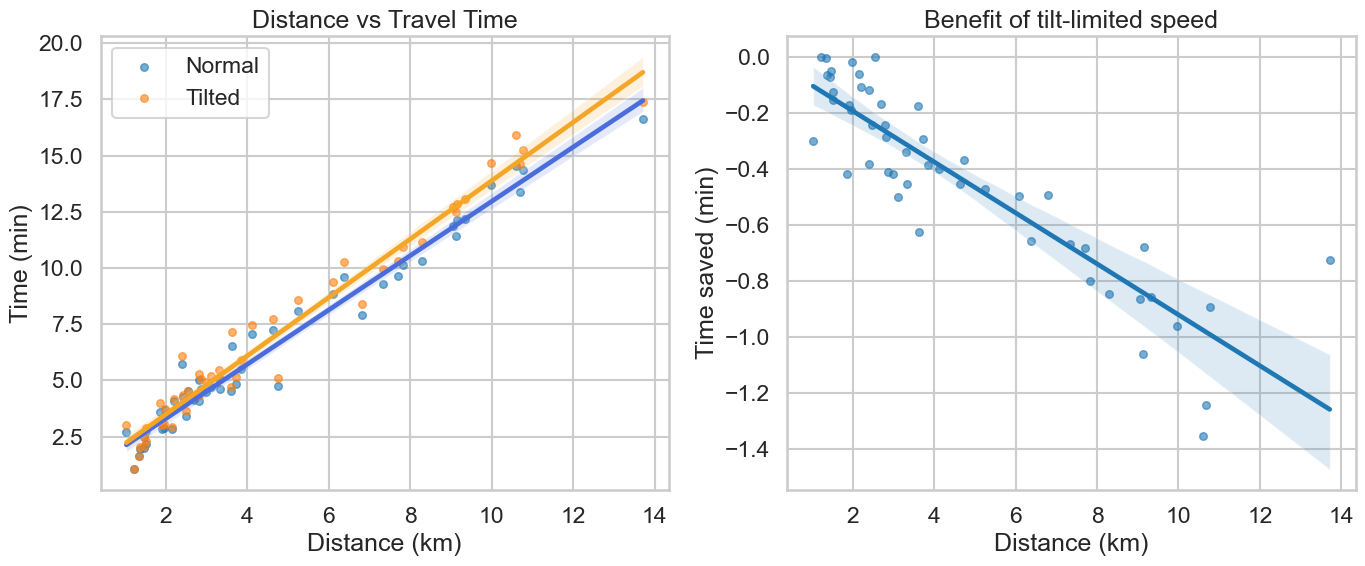

,distance_km,time_legal_min,time_tilt_min,delta_min
count,50.000000,50.000000,50.000000,50.000000
mean,4.661307,6.516800,6.951382,-0.434582
std,3.274342,4.018733,4.323760,0.334601
min,1.028256,1.036667,1.036722,-1.351030
25%,2.171825,3.602917,3.782885,-0.665195
50%,3.319688,4.795000,5.173013,-0.391531
75%,7.196342,9.516667,10.175703,-0.167713
max,13.714749,16.645000,17.370603,-0.000055


In [ ]:
# Scatter plots and regression fits (CORRECTED)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=False)

# Distance vs time
sns.regplot(ax=axes[0], data=results, x="distance_km", y="time_normal_min", scatter_kws={"s":30, "alpha":0.6}, line_kws={"color":"#d62728"}, label="Normal")
sns.regplot(ax=axes[0], data=results, x="distance_km", y="time_tilt_min", scatter_kws={"s":30, "alpha":0.6}, line_kws={"color":"#2ca02c"}, label="Tilted")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Time (min)")
axes[0].legend()
axes[0].set_title("Distance vs Travel Time")

# Time difference vs distance
results["delta_min"] = results["time_normal_min"] - results["time_tilt_min"]
sns.regplot(ax=axes[1], data=results, x="distance_km", y="delta_min", scatter_kws={"s":30, "alpha":0.6}, line_kws={"color":"#1f77b4"})
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Time saved (min)")
axes[1].set_title("Benefit of tilted vehicle")

plt.tight_layout()
plt.show()

results.describe()[["distance_km","time_normal_min","time_tilt_min","delta_min"]]


In [ ]:
# CORRECTED: Normal vs Tilted vehicle timing models
import numpy as _np
from shapely.geometry import LineString as _LineString

def edge_curvature_radius_m(edge_geom: _LineString) -> float:
    try:
        coords = _np.asarray(edge_geom.coords, dtype=float)
    except Exception:
        return float("inf")
    if coords.shape[0] < 3:
        return float("inf")
    p1 = coords[0]
    p3 = coords[-1]
    p2 = coords[coords.shape[0] // 2]
    v21 = p2 - p1
    v31 = p3 - p1
    cross_z = v21[0] * v31[1] - v21[1] * v31[0]
    area2 = abs(cross_z)
    a = float(_np.linalg.norm(v21))
    b = float(_np.linalg.norm(p3 - p2))
    c = float(_np.linalg.norm(v31))
    if area2 < 1e-9 or min(a, b, c) < 1e-6:
        return float("inf")
    s = (a + b + c) / 2.0
    heron_sq = max(0.0, s * (s - a) * (s - b) * (s - c))
    area = max(1e-9, math.sqrt(heron_sq))
    R = (a * b * c) / (4.0 * area)
    return float(R) if _np.isfinite(R) and R > 0 else float("inf")


def normal_edge_travel_time_seconds(edge_data: Dict[str, Any]) -> float:
    """Normal vehicle: limited by curvature, must slow down in turns"""
    length_m = float(edge_data.get("length", 0.0))
    if not _np.isfinite(length_m) or length_m <= 0:
        return 0.0
    speed_kph = edge_data.get("speed_kph", 30.0)
    try:
        speed_kph = float(speed_kph)
    except Exception:
        speed_kph = 30.0
    if not _np.isfinite(speed_kph) or speed_kph <= 0:
        speed_kph = 30.0
    v_legal = speed_kph / 3.6

    # Normal vehicle: limited by curvature
    v_curve = float("inf")
    geom = edge_data.get("geometry")
    if isinstance(geom, _LineString):
        try:
            if length_m >= MIN_EDGE_LENGTH_FOR_CURVATURE_M and geom.length >= MIN_EDGE_LENGTH_FOR_CURVATURE_M:
                R = edge_curvature_radius_m(geom)
                if _np.isfinite(R) and R > 0:
                    v_curve = math.sqrt(LATERAL_A_MAX * R)
        except Exception:
            v_curve = float("inf")

    v_allowed = min(v_legal, v_curve)  # Limited by curvature
    if not _np.isfinite(v_allowed) or v_allowed <= 0:
        v_allowed = max(v_legal, 0.1)
    return length_m / v_allowed


def tilted_edge_travel_time_seconds(edge_data: Dict[str, Any]) -> float:
    """Tilted vehicle: uses full legal speed, no curvature limitation"""
    length_m = float(edge_data.get("length", 0.0))
    if not _np.isfinite(length_m) or length_m <= 0:
        return 0.0
    speed_kph = edge_data.get("speed_kph", 30.0)
    try:
        speed_kph = float(speed_kph)
    except Exception:
        speed_kph = 30.0
    if not _np.isfinite(speed_kph) or speed_kph <= 0:
        speed_kph = 30.0
    v_legal = speed_kph / 3.6

    # Tilted vehicle: no curvature limitation, uses full legal speed
    v_allowed = v_legal
    if not _np.isfinite(v_allowed) or v_allowed <= 0:
        v_allowed = 0.1
    return length_m / v_allowed


def travel_time_normal_seconds(G: nx.MultiDiGraph, route_edges: List[Tuple[int,int,int]]) -> float:
    """Normal vehicle travel time with curvature limitations"""
    moving_time = 0.0
    for e in route_edges:
        data = G.edges[e]
        moving_time += normal_edge_travel_time_seconds(data)
    stop_time = estimate_stop_penalties_seconds(G, route_edges)
    return moving_time + stop_time


def travel_time_tilted_seconds(G: nx.MultiDiGraph, route_edges: List[Tuple[int,int,int]]) -> float:
    """Tilted vehicle travel time without curvature limitations"""
    moving_time = 0.0
    for e in route_edges:
        data = G.edges[e]
        moving_time += tilted_edge_travel_time_seconds(data)
    stop_time = estimate_stop_penalties_seconds(G, route_edges)
    return moving_time + stop_time

